✅ Data Generated Successfully!
Dataset Shape: (1000, 5)


,Age,Gender,Annual_Income,Spending_Score,Purchased
0,56,Male,100,86,1
1,69,Male,133,60,1
2,46,Male,59,12,0
3,32,Female,64,49,0
4,60,Male,115,42,0



✅ Data Preprocessed & Split!

📊 --- MODEL EVALUATION ---
Accuracy: 0.84

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.90      0.88       133
           1       0.79      0.72      0.75        67

    accuracy                           0.84       200
   macro avg       0.83      0.81      0.82       200
weighted avg       0.84      0.84      0.84       200



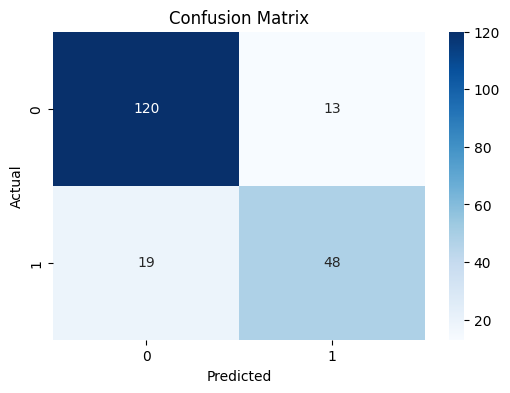


💾 Model saved as 'customer_model.pkl' and 'scaler.pkl'


In [ ]:
# ==========================================
# STEP 1: IMPORT LIBRARIES & GENERATE DATA
# ==========================================
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

# 1. Generate Dummy Data (Since no file was provided)
# We create 1000 customers with features: Age, Gender, Annual_Income, Spending_Score
np.random.seed(42)
n_samples = 1000

data = {
    'Age': np.random.randint(18, 70, n_samples),
    'Gender': np.random.choice(['Male', 'Female'], n_samples),
    'Annual_Income': np.random.randint(20, 140, n_samples), # in $1000s
    'Spending_Score': np.random.randint(1, 100, n_samples), # 1-100 scale
}

df = pd.DataFrame(data)

# Create a 'Purchased' target variable based on some logic + random noise
# (e.g., Higher income & spending score = more likely to buy)
def assign_purchase(row):
    score = (row['Annual_Income'] * 0.4) + (row['Spending_Score'] * 0.6)
    if row['Age'] > 50: score -= 10 # Older people might buy less in this specific logic

    # Add randomness
    score += np.random.randint(-20, 20)

    return 1 if score > 65 else 0

df['Purchased'] = df.apply(assign_purchase, axis=1)

print("✅ Data Generated Successfully!")
print("Dataset Shape:", df.shape)
display(df.head())

# ==========================================
# STEP 2: PREPROCESSING
# ==========================================

# 1. Encode Gender (Male=1, Female=0)
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])

# 2. Split into X (Features) and y (Target)
X = df[['Age', 'Gender', 'Annual_Income', 'Spending_Score']]
y = df['Purchased']

# 3. Train/Test Split (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Scale the Data (Important for accuracy!)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n✅ Data Preprocessed & Split!")

# ==========================================
# STEP 3: MODEL TRAINING (Random Forest)
# ==========================================

# Initialize and Train Random Forest
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)

# Predictions
y_pred = model.predict(X_test_scaled)

# ==========================================
# STEP 4: EVALUATION
# ==========================================
print("\n📊 --- MODEL EVALUATION ---")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ==========================================
# STEP 5: SAVE MODEL FOR WEB APP
# ==========================================
# We save the model and the scaler so we can use them in the app
joblib.dump(model, 'customer_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print("\n💾 Model saved as 'customer_model.pkl' and 'scaler.pkl'")

🔄 Training and Comparing Models...

🏆 FINAL MODEL COMPARISON TABLE:


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.860,0.782609,0.805970,0.794118
3,KNN,0.845,0.781250,0.746269,0.763359
2,Random Forest,0.840,0.786885,0.716418,0.750000
1,Decision Tree,0.810,0.730159,0.686567,0.707692


/tmp/ipython-input-2405139716.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Accuracy", y="Model", data=results_df, palette="viridis")


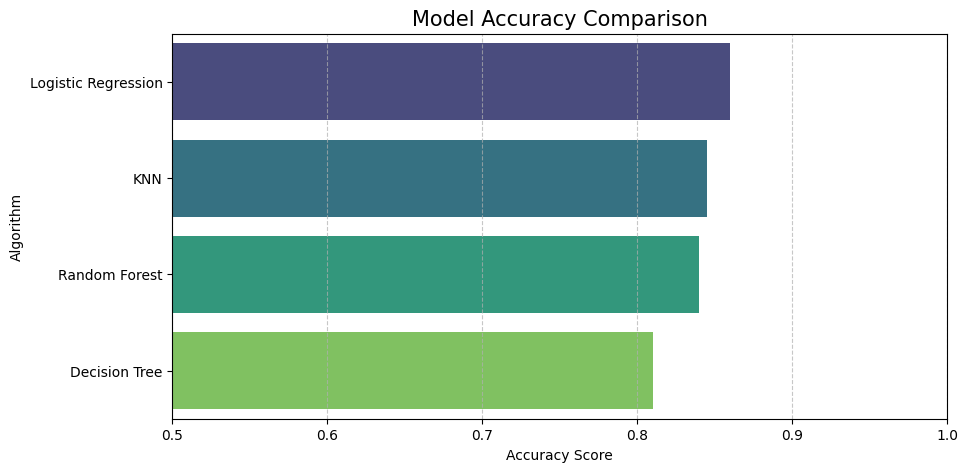


✅ CONCLUSION: The best performing model is **Logistic Regression**.
Use this model for the final web application.


In [ ]:
# ==========================================
# 📊 STEP 6: MODEL COMPARISON & EVALUATION
# ==========================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 1. Define the models we want to compare
# (The PDF asks for at least 2, we will do 4 to impress them)
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

# 2. Dictionary to store results
results = []

print("🔄 Training and Comparing Models...")

# 3. Loop through each model to train and evaluate
for name, model in models.items():
    model.fit(X_train_scaled, y_train) # Train
    y_pred = model.predict(X_test_scaled) # Predict

    # Calculate Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1
    })

# 4. Create a DataFrame for the Final Report
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="Accuracy", ascending=False)

# Display the data table (Take a screenshot of this!)
print("\n🏆 FINAL MODEL COMPARISON TABLE:")
display(results_df)

# 5. Visualize the Comparison (Take a screenshot of this too!)
plt.figure(figsize=(10, 5))
sns.barplot(x="Accuracy", y="Model", data=results_df, palette="viridis")
plt.xlim(0.5, 1.0)
plt.title("Model Accuracy Comparison", fontsize=15)
plt.xlabel("Accuracy Score")
plt.ylabel("Algorithm")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# 6. Conclusion
best_model = results_df.iloc[0]['Model']
print(f"\n✅ CONCLUSION: The best performing model is **{best_model}**.")
print("Use this model for the final web application.")